In [85]:
!pip install faker pandas networkx matplotlib

### Вариант 6. Недвижимость и сделки
Сущности: 
- Объект недвижимости: id, адрес, тип (квартира/дом/коммерческое), площадь, количество комнат, этаж, год постройки, кадастровый номер.
- Владелец: id, ФИО, паспортные данные, доля (если долевая собственность).
- Сделка купли-продажи: id, дата, id объекта, id продавца, id покупателя, цена, нотариус.
- Ценовой архив: id объекта, дата изменения, новая цена (для отслеживания динамики).

Объём: 2000 объектов, 300 владельцев, 150 сделок, у каждого объекта 2–3 записи цен.

Онтология:
- Классы: Объект, Владелец, Сделка, ЦеновойАрхив.
- Связи: объект может иметь нескольких владельцев (доли), сделка связывает продавца, покупателя и объект.

In [86]:
import pandas as pd
import random
import json
from faker import Faker
from datetime import datetime, timedelta
import networkx as nx
import matplotlib.pyplot as plt

In [87]:
fake = Faker('ru_RU') # создаём генератор с русской локализацией
Faker.seed(42)
random.seed(42)

In [88]:
# Владельцы
def generate_owners(n: int) -> pd.DataFrame:
    owners = []
    for i in range(1, n + 1):
        passport_series = random.randint(1000, 9999)
        passport_number = random.randint(100000, 999999)
        owners.append({
            'owner_id': i,
            'full_name': fake.name(),
            'passport_series': passport_series,
            'passport_number': passport_number,
            'passport_issued_by': fake.company(),  # кем выдан
            'address': fake.address().replace('\n', ', '),
            'phone': fake.phone_number(),
            'email': fake.email()
        })
    return pd.DataFrame(owners)

In [89]:
# 2. Объекты недвижимости 
def generate_properties(n: int, owner_ids: list) -> pd.DataFrame:
    property_types = ['Квартира', 'Дом', 'Коммерческое']
    properties = []
    
    for i in range(1, n + 1):
        # Выбираем количество владельцев (1, 2 или 3)
        num_owners = random.choices([1, 2, 3], weights=[0.7, 0.2, 0.1])[0]
        
        # Выбираем случайных владельцев
        selected_owners = random.sample(owner_ids, num_owners)
        
        # Если один владелец - доля 100%
        if num_owners == 1:
            shares = [1.0]
        else:
            # Если владельцев несколько - распределяем доли
            shares = []
            remaining = 1.0 # остаток суммы долей, который нужно распределить
            for j in range(num_owners - 1): #для всех, кроме последнего владельца
                share = round(random.uniform(0.1, remaining - 0.1), 2)
                # выбирает случайное дробное число от 0.1 до (remaining - 0.1).
                #  Нижняя граница 0.1, чтобы доля была не менее 10%.
                #  Верхняя граница – остаток минус 0.1, чтобы последний владелец тоже
                #  получил хотя бы 0.1.
                
                shares.append(share)
                remaining -= share
            shares.append(round(remaining, 2))
        
        # Упаковываем владельцев и доли в список словарей
        owners_with_shares = []
        for k in range(num_owners):
            owners_with_shares.append({
                'owner_id': selected_owners[k],
                'share': shares[k]
            })
        
        # Превращаем список в JSON строку
        owner_info_json = json.dumps(owners_with_shares, ensure_ascii=False)
        
        # Собираем объект
        properties.append({
            'property_id': i,
            'address': fake.address().replace('\n', ', '),
            'property_type': random.choice(property_types),
            'area': round(random.uniform(20.0, 200.0), 1),
            'rooms': random.randint(1, 5),
            'floor': random.randint(1, 25),
            'build_year': random.randint(1950, 2024),
            'cadastral_number': f"{random.randint(10, 99)}:{random.randint(10, 99)}:{random.randint(100000, 999999)}:{random.randint(1, 999)}",
            'owner_info': owner_info_json
        })
    
    return pd.DataFrame(properties)

In [90]:
# 3. Ценовой архив
def generate_price_history(properties_df: pd.DataFrame, avg_records: int = 2) -> pd.DataFrame:
    history = []
    record_id = 1
    start_date = datetime(2015, 1, 1)
    end_date = datetime.now()
    
    for _, prop in properties_df.iterrows():
        prop_id = prop['property_id']
        base_price = random.randint(1_000_000, 20_000_000)  # начальная цена
        
        # Количество изменений цены
        num_changes = random.choices([0, 1, 2, 3], weights=[0.3, 0.4, 0.2, 0.1])[0] #как часто менялась цена
        change_dates = sorted([fake.date_between(start_date=start_date, end_date=end_date) #даты изменений цены
                               for _ in range(num_changes)])
        
        # Цены с динамикой (рост или падение)
        all_dates = [start_date.date()] + change_dates #первая дата и даты изменений
        all_prices = [base_price] #начинается с начальной цены
        for _ in range(num_changes):
            change = random.uniform(-0.15, 0.25)  # от -15% до +25%
            new_price = int(all_prices[-1] * (1 + change)) #предыдущая цена × (1 + change)
            all_prices.append(new_price)
        
        for i in range(len(all_dates)):
            history.append({
                'price_history_id': record_id,
                'property_id': prop_id,
                'change_date': all_dates[i],
                'new_price': all_prices[i]
            })
            record_id += 1
    return pd.DataFrame(history)

In [91]:
# 4. Сделки купли-продажи
def generate_transactions(n: int, properties_df: pd.DataFrame, owners_df: pd.DataFrame) -> pd.DataFrame:
    transactions = []
    for i in range(1, n + 1):
        property_row = properties_df.sample(1).iloc[0] 
        property_id = property_row['property_id']
        # Продавец – один из текущих владельцев
        current_owners = json.loads(property_row['owner_info'])
        seller_id = random.choice(current_owners)['owner_id']
        # Покупатель – другой владелец (из списка всех, кроме продавца)
        other_owners = owners_df[owners_df['owner_id'] != seller_id]['owner_id'].tolist()
        buyer_id = random.choice(other_owners)
        
        transaction_date = fake.date_between(start_date='-5y', end_date='today')
        price = random.randint(500_000, 30_000_000)
        
        transactions.append({
            'transaction_id': i,
            'date': transaction_date,
            'property_id': property_id,
            'seller_id': seller_id,
            'buyer_id': buyer_id,
            'price': price,
            'notary': fake.name()
        })
    return pd.DataFrame(transactions)

In [92]:
# Параметры объёмов данных
N_OWNERS = 300
N_PROPERTIES = 2000
N_TRANSACTIONS = 150

In [93]:
# Генерация DataFrame'ов
owners_df = generate_owners(N_OWNERS)
properties_df = generate_properties(N_PROPERTIES, owners_df['owner_id'].tolist())
price_history_df = generate_price_history(properties_df, avg_records=2)
transactions_df = generate_transactions(N_TRANSACTIONS, properties_df, owners_df)

In [94]:
# Просмотр первых записей
print("=== Владельцы ===")
display(owners_df.head())

print("=== Объекты недвижимости ===")
display(properties_df.head())

print("=== Ценовой архив ===")
display(price_history_df.head())

print("=== Сделки ===")
display(transactions_df.head())

=== Владельцы ===


,owner_id,full_name,passport_series,passport_number,passport_issued_by,address,phone,email
0,1,Козлова Ирина Ефимовна,2824,126225,АО «Чернова Ершов»,"г. Артем, алл. Лесозаводская, д. 983, 379402",8 542 351 16 15,ernest_40@example.net
1,2,Владилен Матвеевич Федоров,5506,356787,Сафонов Лимитед,"клх Братск, бул. Курский, д. 2, 164752",8 534 192 8327,opotapov@example.net
2,3,Зимина Лидия Аркадьевна,4657,246316,ОАО «Голубев Калашникова»,"к. Бологое, пер. Островского, д. 77, 242388",+79696532871,samolovavalerija@example.org
3,4,Вишнякова Наталья Эльдаровна,2679,809570,НПО «Фадеев»,"д. Александров Гай, бул. Донской, д. 6 стр. 34...",+78932528809,selivan_01@example.com
4,5,Ксения Егоровна Павлова,9935,191161,ЗАО «Фомичева Яковлев»,"ст. Боровск, ш. Кедровое, д. 97 стр. 94, 383465",8 (871) 331-50-98,haritonpoljakov@example.org


=== Объекты недвижимости ===


,property_id,address,property_type,area,rooms,floor,build_year,cadastral_number,owner_info
0,1,"клх Муравленко, пер. Тельмана, д. 2/1 стр. 223...",Коммерческое,77.1,4,20,2014,64:80:567574:919,"[{""owner_id"": 287, ""share"": 1.0}]"
1,2,"ст. Радужный, ул. Сплавная, д. 801, 902517",Дом,66.7,2,21,1985,76:72:757193:245,"[{""owner_id"": 244, ""share"": 1.0}]"
2,3,"клх Хужир, алл. Привольная, д. 8 стр. 5/4, 268319",Коммерческое,71.4,3,11,1990,79:20:245095:155,"[{""owner_id"": 40, ""share"": 1.0}]"
3,4,"п. Асбест, ул. Терешковой, д. 9/2, 287339",Коммерческое,58.5,4,14,1992,79:69:535970:64,"[{""owner_id"": 79, ""share"": 1.0}]"
4,5,"к. Южно-Сахалинск, ш. Придорожное, д. 776 стр....",Дом,182.9,5,23,1952,83:58:600149:7,"[{""owner_id"": 216, ""share"": 1.0}]"


=== Ценовой архив ===


,price_history_id,property_id,change_date,new_price
0,1,1,2015-01-01,11770469
1,2,1,2022-10-05,11517304
2,3,1,2025-11-03,11285686
3,4,2,2015-01-01,7071494
4,5,2,2020-07-25,6874266


=== Сделки ===


,transaction_id,date,property_id,seller_id,buyer_id,price,notary
0,1,2024-02-21,1115,202,169,22338917,Зиновий Викентьевич Исаков
1,2,2021-12-27,1838,246,215,13937210,Ефим Ефимович Беспалов
2,3,2021-12-01,1682,241,35,29938806,Лихачева Евфросиния Романовна
3,4,2022-01-09,435,127,111,21360792,Карл Геннадиевич Евсеев
4,5,2022-06-09,931,241,99,14887883,Голубев Марк Фадеевич


In [95]:
# Сохранение в CSV
owners_df.to_csv('owners.csv', index=False)
properties_df.to_csv('properties.csv', index=False)
price_history_df.to_csv('price_history.csv', index=False)
transactions_df.to_csv('transactions.csv', index=False)

print("CSV файлы сохранены: owners.csv, properties.csv, price_history.csv, transactions.csv")


CSV файлы сохранены: owners.csv, properties.csv, price_history.csv, transactions.csv


Онтология сохранена в real_estate_ontology.owl
Классы: [real_estate_ontology.ОбъектНедвижимости, real_estate_ontology.Владелец, real_estate_ontology.Сделка, real_estate_ontology.ЦеновойАрхив, real_estate_ontology.Покупатель, real_estate_ontology.Продавец]
Свойства: [real_estate_ontology.владеет, real_estate_ontology.продавец, real_estate_ontology.покупатель, real_estate_ontology.объект_в_сделке, real_estate_ontology.имеет_ценовую_историю, real_estate_ontology.участвует, real_estate_ontology.имеет]


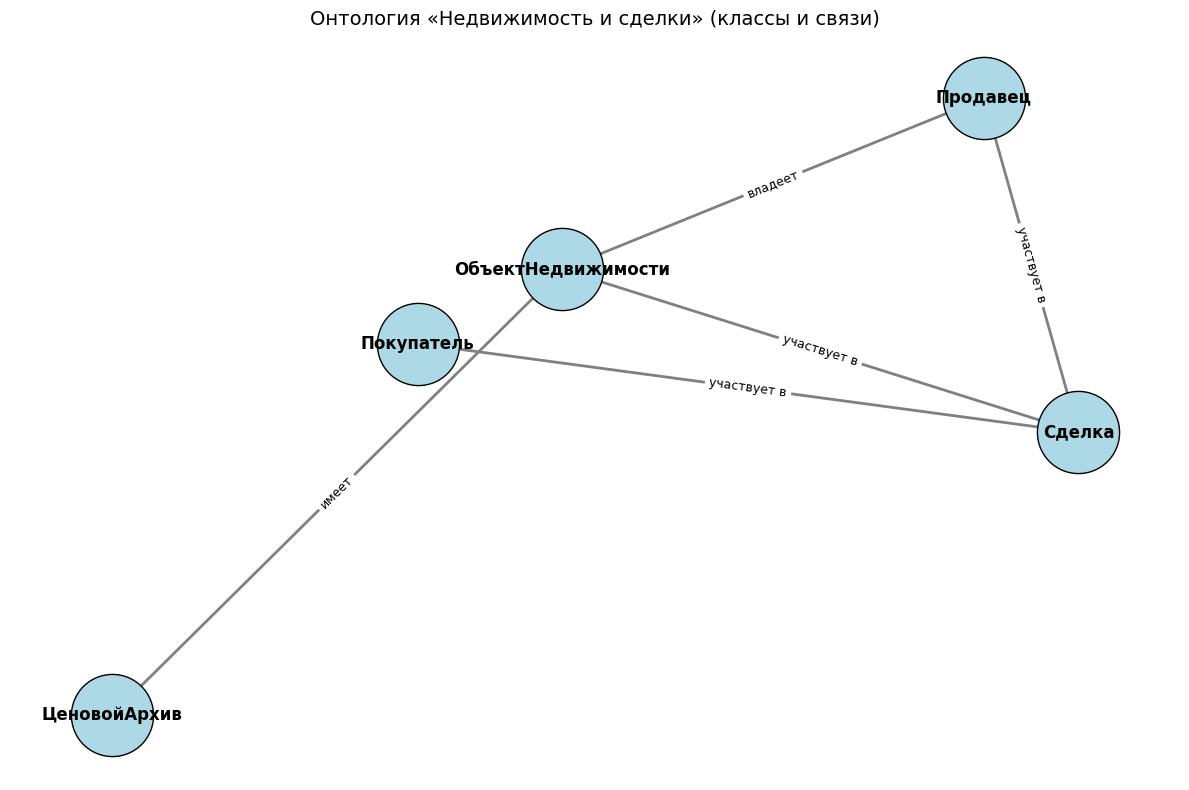

In [96]:
# Установка библиотек 
!pip install owlready2 networkx matplotlib

from owlready2 import *
import networkx as nx
import matplotlib.pyplot as plt

# 1. Создаём пустую онтологию
onto = get_ontology("http://example.org/real_estate_ontology.owl")

# 2. Определяем классы и свойства
with onto:
    #  Классы
    class ОбъектНедвижимости(Thing):
        pass

    class Владелец(Thing):
        pass

    class Сделка(Thing):
        pass

    class ЦеновойАрхив(Thing):
        pass

    class Покупатель(Thing):
        pass  

    class Продавец(Thing):
        pass

    # Объектные свойства (связи) 
#    class владеет(ObjectProperty):
#        domain = [Владелец]
#        range = [ОбъектНедвижимости]
#        comment = "Владелец владеет объектом"

    class владеет(ObjectProperty):
        domain = [Покупатель]
        range = [ОбъектНедвижимости]
        comment = "Покупатель владеет объектом"

    class участвует(ObjectProperty):
        domain = [Покупатель]
        range = [Сделка]
        comment = "Покупатель участвует в сделке"

    class участвует(ObjectProperty):
        domain = [Продавец]
        range = [Сделка]
        comment = "Продавец участвует в сделке"

#    class продавец(ObjectProperty):
#        domain = [Сделка]
#        range = [Владелец]
#        comment = "В сделке участвует продавец"

#    class покупатель(ObjectProperty):
#        domain = [Сделка]
#        range = [Владелец]
#        comment = "В сделке участвует покупатель"


    class участвует(ObjectProperty):
        domain = [ОбъектНедвижимости]
        range = [Сделка]
        comment = "Объект недвижимости участвует в сделке"

    class имеет(ObjectProperty):
        domain = [ОбъектНедвижимости]
        range = [ЦеновойАрхив]
        comment = "Объект имеет записи в ценовом архиве"

# 3. Сохраняем онтологию в файл
onto.save(file="real_estate_ontology.owl", format="rdfxml")
print("Онтология сохранена в real_estate_ontology.owl")
print("Классы:", list(onto.classes()))
print("Свойства:", list(onto.object_properties()))

# 4. Строим онтограф
G = nx.DiGraph()

# Узлы – классы
classes = ['ОбъектНедвижимости', 'Сделка', 'ЦеновойАрхив', 'Покупатель', 'Продавец']
G.add_nodes_from(classes)

# Рёбра – в соответствии с domain → range
edges = [
    ('Продавец', 'ОбъектНедвижимости'),   # владеет
    ('Продавец', 'Сделка'), 
    ('Покупатель', 'Сделка'), 
    #('Сделка', 'Владелец'),              # продавец и покупатель
    ('ОбъектНедвижимости', 'Сделка'),    # объект_в_сделке
    ('ОбъектНедвижимости', 'ЦеновойАрхив') # имеет_ценовую_историю

]
G.add_edges_from(edges)

# Рисуем граф
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=1.2)
nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='lightblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2)

# Подписи рёбер (с учётом, что от Сделки к Владельцу идут две разные связи)
edge_labels = {
    ('Продавец', 'ОбъектНедвижимости'): 'владеет',
    ('Продавец', 'Сделка'): 'участвует в',
    ('Покупатель', 'Сделка'): 'участвует в',
#    ('Сделка', 'Владелец'): 'продавец / покупатель',
    ('ОбъектНедвижимости', 'Сделка'): 'участвует в',
    ('ОбъектНедвижимости', 'ЦеновойАрхив'): 'имеет'
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Онтология «Недвижимость и сделки» (классы и связи)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

In [107]:
# Установка необходимых библиотек
!pip install owlready2 networkx matplotlib pandas -q

from owlready2 import *
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import json

# Загружаем сгенерированные данные
owners_df = pd.read_csv('owners.csv')
properties_df = pd.read_csv('properties.csv')
price_history_df = pd.read_csv('price_history.csv')
transactions_df = pd.read_csv('transactions.csv')

print("Данные загружены:")
print(f"   Владельцев: {len(owners_df)}")
print(f"   Объектов недвижимости: {len(properties_df)}")
print(f"   Записей ценового архива: {len(price_history_df)}")
print(f"   Сделок: {len(transactions_df)}")

# 1. СОЗДАНИЕ ОНТОЛОГИИ С ИНДИВИДУАЛЬНОСТЯМИ

# Создаём новую онтологию
onto = get_ontology("http://example.org/real_estate_instances.owl")

with onto:
    # ОПРЕДЕЛЕНИЕ КЛАССОВ 
    class Property(Thing):  # ОбъектНедвижимости
        pass
    
    class Owner(Thing):     # Владелец
        pass
    
    class Transaction(Thing):  # Сделка
        pass
    
    class PriceHistory(Thing):  # ЦеновойАрхив
        pass
    
    # ОПРЕДЕЛЕНИЕ ДАТАПРОПЕРТИ ДЛЯ ОБЪЕКТОВ НЕДВИЖИМОСТИ
    class has_property_id(DataProperty):
        domain = [Property]
        range = [int]
    
    class has_address(DataProperty):
        domain = [Property]
        range = [str]
    
    class has_property_type(DataProperty):
        domain = [Property]
        range = [str]
    
    class has_area(DataProperty):
        domain = [Property]
        range = [float]
    
    class has_rooms(DataProperty):
        domain = [Property]
        range = [int]
    
    class has_floor(DataProperty):
        domain = [Property]
        range = [int]
    
    class has_build_year(DataProperty):
        domain = [Property]
        range = [int]
    
    class has_cadastral_number(DataProperty):
        domain = [Property]
        range = [str]
    
    # ОПРЕДЕЛЕНИЕ ДАТАПРОПЕРТИ ДЛЯ ВЛАДЕЛЬЦЕВ
    class has_owner_id(DataProperty):
        domain = [Owner]
        range = [int]
    
    class has_full_name(DataProperty):
        domain = [Owner]
        range = [str]
    
    class has_passport_series(DataProperty):
        domain = [Owner]
        range = [int]
    
    class has_passport_number(DataProperty):
        domain = [Owner]
        range = [int]
    
    class has_passport_issued_by(DataProperty):
        domain = [Owner]
        range = [str]
    
    class has_owner_address(DataProperty):
        domain = [Owner]
        range = [str]
    
    class has_phone(DataProperty):
        domain = [Owner]
        range = [str]
    
    class has_email(DataProperty):
        domain = [Owner]
        range = [str]
    
    # ОПРЕДЕЛЕНИЕ ДАТАПРОПЕРТИ ДЛЯ СДЕЛОК
    class has_transaction_id(DataProperty):
        domain = [Transaction]
        range = [int]
    
    class has_transaction_date(DataProperty):
        domain = [Transaction]
        range = [str]
    
    class has_transaction_price(DataProperty):
        domain = [Transaction]
        range = [int]
    
    class has_notary(DataProperty):
        domain = [Transaction]
        range = [str]
    
    # ОПРЕДЕЛЕНИЕ ДАТАПРОПЕРТИ ДЛЯ ЦЕНОВОГО АРХИВА
    class has_price_history_id(DataProperty):
        domain = [PriceHistory]
        range = [int]
    
    class has_change_date(DataProperty):
        domain = [PriceHistory]
        range = [str]
    
    class has_new_price(DataProperty):
        domain = [PriceHistory]
        range = [int]
    
    # ОПРЕДЕЛЕНИЕ ДАТАПРОПЕРТИ ДЛЯ ДОЛЕЙ ВЛАДЕНИЯ
    class has_ownership_share(DataProperty):
        domain = [Owner]
        range = [float]
    
    # ОПРЕДЕЛЕНИЕ ОБЪЕКТНЫХ СВОЙСТВ
    class owns(ObjectProperty):          # владеет
        domain = [Owner]
        range = [Property]
    
    class seller_in(ObjectProperty):      # продавец в сделке
        domain = [Owner]
        range = [Transaction]
    
    class buyer_in(ObjectProperty):       # покупатель в сделке
        domain = [Owner]
        range = [Transaction]
    
    class has_seller(ObjectProperty):     # сделка имеет продавца
        domain = [Transaction]
        range = [Owner]
    
    class has_buyer(ObjectProperty):      # сделка имеет покупателя
        domain = [Transaction]
        range = [Owner]
    
    class has_property(ObjectProperty):   # сделка связана с объектом
        domain = [Transaction]
        range = [Property]
    
    class has_price_record(ObjectProperty):  # объект имеет ценовую историю
        domain = [Property]
        range = [PriceHistory]

# 2. СОЗДАНИЕ ИНДИВИДУАЛЬНОСТЕЙ 

with onto:
    print("\n" + "="*60)
    print("СОЗДАНИЕ ИНДИВИДУАЛЬНОСТЕЙ В ОНТОЛОГИИ")
    print("="*60)
    
    # Берем первые 3 объекта, 5 владельцев, 3 сделки
    sample_properties = properties_df.head(10).to_dict('records')
    sample_owners = owners_df.head(10).to_dict('records')
    sample_transactions = transactions_df.head(10).to_dict('records')
    sample_price_history = price_history_df.head(10).to_dict('records')
    
    property_instances = {}
    owner_instances = {}
    transaction_instances = {}
    price_history_instances = {}
    
    # СОЗДАНИЕ ВЛАДЕЛЬЦЕВ (Owner instances)
    print("\n--- СОЗДАНИЕ ВЛАДЕЛЬЦЕВ (Owner) ---")
    for owner in sample_owners:
        owner_uri = f"Owner_{owner['owner_id']}"
        owner_instance = Owner(owner_uri)
        
        owner_instance.has_owner_id.append(owner['owner_id'])
        owner_instance.has_full_name.append(owner['full_name'])
        owner_instance.has_passport_series.append(owner['passport_series'])
        owner_instance.has_passport_number.append(owner['passport_number'])
        owner_instance.has_passport_issued_by.append(owner['passport_issued_by'])
        owner_instance.has_owner_address.append(owner['address'])
        owner_instance.has_phone.append(owner['phone'])
        owner_instance.has_email.append(owner['email'])
        
        owner_instances[owner['owner_id']] = owner_instance
        print(f"   Создан владелец: {owner['full_name'][:35]}... (ID: {owner['owner_id']})")
    
    # СОЗДАНИЕ ОБЪЕКТОВ НЕДВИЖИМОСТИ (Property instances)
    print("\n--- СОЗДАНИЕ ОБЪЕКТОВ НЕДВИЖИМОСТИ (Property) ---")
    for prop in sample_properties:
        prop_uri = f"Property_{prop['property_id']}"
        prop_instance = Property(prop_uri)
        
        prop_instance.has_property_id.append(prop['property_id'])
        prop_instance.has_address.append(prop['address'])
        prop_instance.has_property_type.append(prop['property_type'])
        prop_instance.has_area.append(prop['area'])
        prop_instance.has_rooms.append(prop['rooms'])
        prop_instance.has_floor.append(prop['floor'])
        prop_instance.has_build_year.append(prop['build_year'])
        prop_instance.has_cadastral_number.append(prop['cadastral_number'])
        
        property_instances[prop['property_id']] = prop_instance
        print(f"   Создан объект: {prop['property_type']}, {prop['area']} кв.м (ID: {prop['property_id']})")
        
        # СВЯЗИ: владельцы и доли
        owner_info = json.loads(prop['owner_info'])
        for info in owner_info:
            owner_id = info['owner_id']
            share = info['share']
            
            if owner_id in owner_instances:
                # Связь владелец -> объект
                owner_instances[owner_id].owns.append(prop_instance)
                # Добавляем долю как датапроперти
                owner_instances[owner_id].has_ownership_share.append(share)
                print(f"      -> Связь: Владелец {owner_id} владеет (доля: {share*100:.0f}%)")
    
    # СОЗДАНИЕ ЗАПИСЕЙ ЦЕНОВОГО АРХИВА (PriceHistory instances)
    print("\n--- СОЗДАНИЕ ЗАПИСЕЙ ЦЕНОВОГО АРХИВА (PriceHistory) ---")
    for ph in sample_price_history:
        ph_uri = f"PriceHistory_{ph['price_history_id']}"
        ph_instance = PriceHistory(ph_uri)
        
        ph_instance.has_price_history_id.append(ph['price_history_id'])
        ph_instance.has_change_date.append(str(ph['change_date']))
        ph_instance.has_new_price.append(ph['new_price'])
        
        price_history_instances[ph['price_history_id']] = ph_instance
        
        # СВЯЗЬ: объект -> ценовая история
        prop_id = ph['property_id']
        if prop_id in property_instances:
            property_instances[prop_id].has_price_record.append(ph_instance)
            print(f"   Запись #{ph['price_history_id']}: объект {prop_id} - {ph['new_price']:,} руб. ({ph['change_date']})")
    
    # СОЗДАНИЕ СДЕЛОК (Transaction instances)
    print("\n--- СОЗДАНИЕ СДЕЛОК (Transaction) ---")
    for trans in sample_transactions:
        trans_uri = f"Transaction_{trans['transaction_id']}"
        trans_instance = Transaction(trans_uri)
        
        trans_instance.has_transaction_id.append(trans['transaction_id'])
        trans_instance.has_transaction_date.append(str(trans['date']))
        trans_instance.has_transaction_price.append(trans['price'])
        trans_instance.has_notary.append(trans['notary'])
        
        transaction_instances[trans['transaction_id']] = trans_instance
        print(f"   Создана сделка #{trans['transaction_id']}: {trans['price']:,} руб. (нотариус: {trans['notary'][:20]}...)")
        
        # СВЯЗЬ: сделка -> объект
        prop_id = trans['property_id']
        if prop_id in property_instances:
            trans_instance.has_property.append(property_instances[prop_id])
            print(f"      -> Связь: сделка #{trans['transaction_id']} → объект {prop_id}")
        
        # СВЯЗИ: продавец и покупатель
        seller_id = trans['seller_id']
        buyer_id = trans['buyer_id']
        
        if seller_id in owner_instances:
            trans_instance.has_seller.append(owner_instances[seller_id])
            owner_instances[seller_id].seller_in.append(trans_instance)
            print(f"      -> Связь: продавец ID {seller_id}")
        
        if buyer_id in owner_instances:
            trans_instance.has_buyer.append(owner_instances[buyer_id])
            owner_instances[buyer_id].buyer_in.append(trans_instance)
            print(f"      -> Связь: покупатель ID {buyer_id}")

# Сохраняем онтологию
onto.save(file="real_estate_ontology_with_instances.owl", format="rdfxml")

print("\n" + "="*60)
print("ОНТОЛОГИЯ С ИНДИВИДУАЛЬНОСТЯМИ СОЗДАНА")
print(f"   Файл сохранён: real_estate_ontology_with_instances.owl")
print(f"   Классы: {[c.name for c in onto.classes()]}")
print(f"   Индивидуальности: {len(list(onto.individuals()))}")
print(f"   Объектные свойства: {[p.name for p in onto.object_properties()]}")
print("="*60)

Данные загружены:
   Владельцев: 300
   Объектов недвижимости: 2000
   Записей ценового архива: 4142
   Сделок: 150

СОЗДАНИЕ ИНДИВИДУАЛЬНОСТЕЙ В ОНТОЛОГИИ

--- СОЗДАНИЕ ВЛАДЕЛЬЦЕВ (Owner) ---
   Создан владелец: Козлова Ирина Ефимовна... (ID: 1)
   Создан владелец: Владилен Матвеевич Федоров... (ID: 2)
   Создан владелец: Зимина Лидия Аркадьевна... (ID: 3)
   Создан владелец: Вишнякова Наталья Эльдаровна... (ID: 4)
   Создан владелец: Ксения Егоровна Павлова... (ID: 5)
   Создан владелец: Евдокимов Аристарх Давыдович... (ID: 6)
   Создан владелец: Суворов Ипат Артемьевич... (ID: 7)
   Создан владелец: Анастасия Альбертовна Логинова... (ID: 8)
   Создан владелец: Феоктист Бориславович Богданов... (ID: 9)
   Создан владелец: Антонин Бенедиктович Калашников... (ID: 10)

--- СОЗДАНИЕ ОБЪЕКТОВ НЕДВИЖИМОСТИ (Property) ---
   Создан объект: Коммерческое, 77.1 кв.м (ID: 1)
   Создан объект: Дом, 66.7 кв.м (ID: 2)
   Создан объект: Коммерческое, 71.4 кв.м (ID: 3)
   Создан объект: Коммерческое